In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from statsmodels.formula.api import ols
import mplcyberpunk as mpc
import scipy.stats as stats

In [46]:
# apply theme to all plots
plt.style.use("cyberpunk")

# pandas setting to  display all columns 
# pd.set_option('display.max_columns', None)

# Ways of creating a dataframe:
## 1 - A dictionary of list of column values
Here `key` - column name & `val` - list of values for that column

In [3]:
# a dictionary of column : column_values
datadf1 = {"Name": ["Alice", "Bob" , "Charlie","Mike"],
        "Age": [26, 27,29,30],
        "City": ["New York" , "London" , "Paris","Los Angeles"],
        "join_date":["2025-10-01", "2024-09-23" , "2025-06-10" , "2025-01-10"]}

# Loading as a dataframe
df1 = pd.DataFrame(datadf1)

# Converting join_date column to datetime format
df1["join_date"] = pd.to_datetime(df1["join_date"])

print(df1.dtypes)
print(df1)

Name                    str
Age                   int64
City                    str
join_date    datetime64[us]
dtype: object
      Name  Age         City  join_date
0    Alice   26     New York 2025-10-01
1      Bob   27       London 2024-09-23
2  Charlie   29        Paris 2025-06-10
3     Mike   30  Los Angeles 2025-01-10


In [4]:
# Extracting only specific part of dates
df1["join_date"].dt.month_name()

0      October
1    September
2         June
3      January
Name: join_date, dtype: str

## Filtering rows / columns using `loc` & `iloc`

In [5]:
# Filtering based on iloc - works similar to lists indexing
df1.iloc[1, 1] = 28
print(df1)

      Name  Age         City  join_date
0    Alice   26     New York 2025-10-01
1      Bob   28       London 2024-09-23
2  Charlie   29        Paris 2025-06-10
3     Mike   30  Los Angeles 2025-01-10


In [6]:
# Creating a copy of the dataset
df2 = df1.copy()
df2.set_index("Name", inplace=True)

In [7]:
# filtering using loc - used for named indexes
df2.loc["Bob":"Mike",['Age','join_date']]

,Age,join_date
Name,,
Bob,28,2024-09-23
Charlie,29,2025-06-10
Mike,30,2025-01-10


# Probability revision

In [8]:
df = pd.read_csv('../statistics_in_python/stats_datasets/weightsheights.csv', usecols=["Height in cm" , "Weight in kg"]).round(2)
df.columns = df.columns.str.replace(' ', '_')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Height_in_cm  25000 non-null  float64
 1   Weight_in_kg  25000 non-null  float64
dtypes: float64(2)
memory usage: 390.8 KB


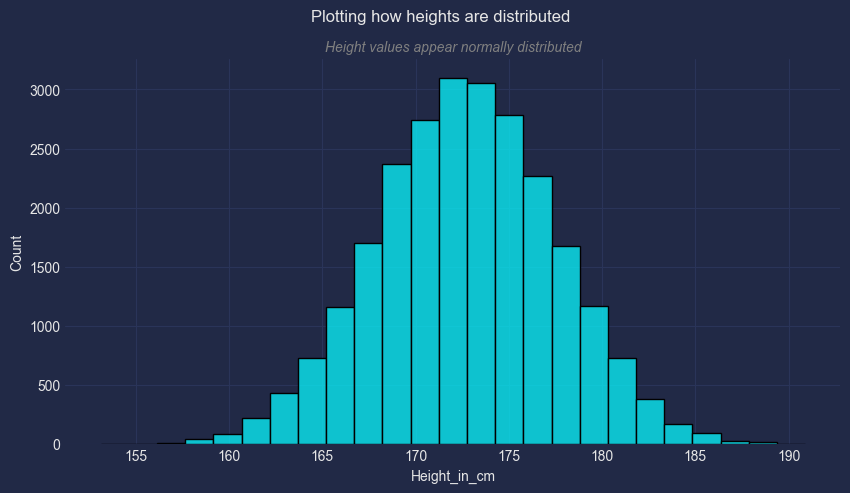

In [9]:
# Finding kind of distribution for the height values 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()

> Thus its observed that majority of heights are between 168-176 cm, quantiles will give better idea

In [10]:
the_quantiles = [0.25, 0.5 , 0.75, 1]

for each in the_quantiles: 
    print(f"Heights in {each}-ile : {np.quantile(df["Height_in_cm"],each)}")    


Heights in 0.25-ile : 169.43
Heights in 0.5-ile : 172.71
Heights in 0.75-ile : 175.95
Heights in 1-ile : 190.89


Text(0.5, 1.0, 'Overview of statistics using boxplot')

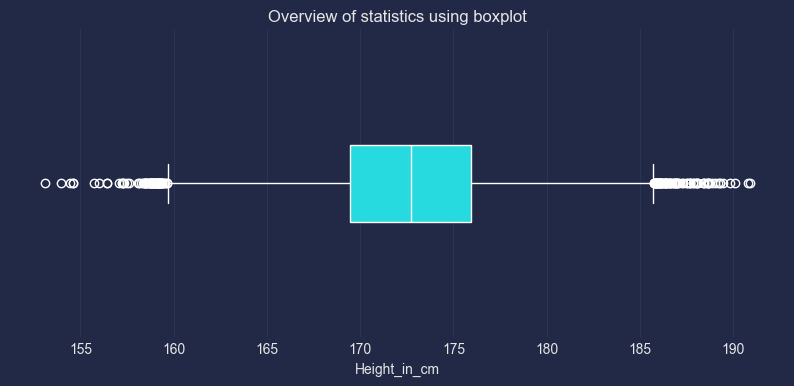

In [11]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Height_in_cm", width=0.25, flierprops={"markeredgecolor":"white"},linecolor='white')
plt.title("Overview of statistics using boxplot")

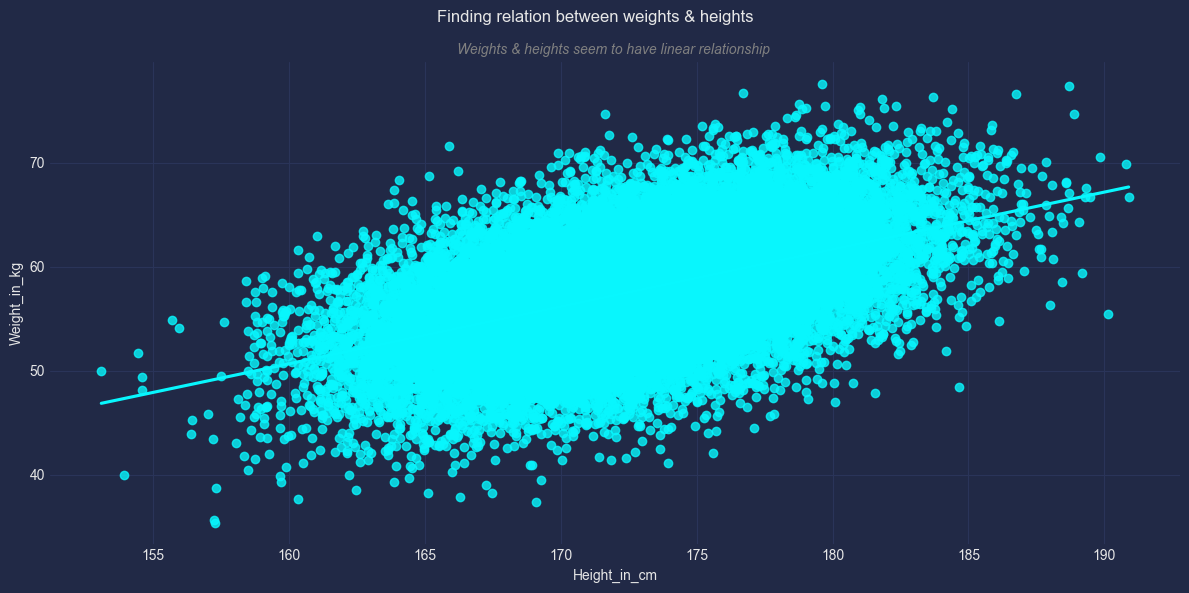

In [12]:
# Finding relation between weights & heights
plt.figure(figsize=(12,6))
sns.regplot(data=df , x= 'Height_in_cm' , y='Weight_in_kg', ci=None)
plt.suptitle('Finding relation between weights & heights')
plt.title("Weights & heights seem to have linear relationship " , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.tight_layout()
plt.show()


## Determining the fit  

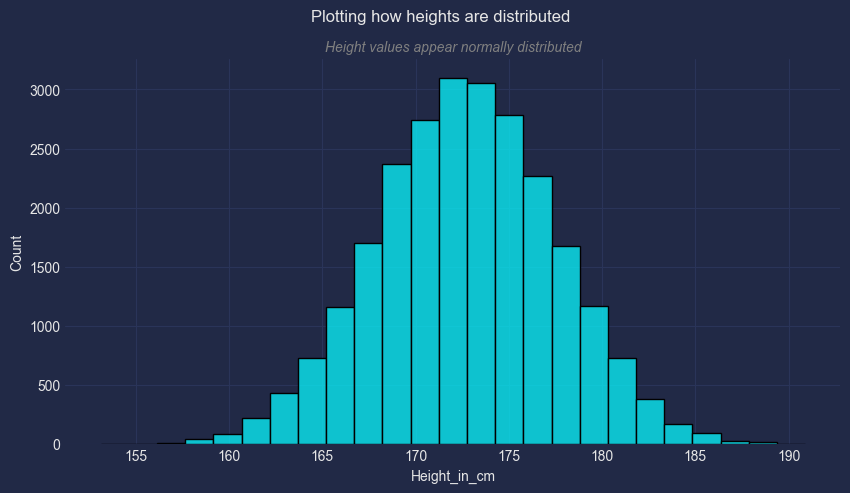

In [13]:
# Finding kind of distribution for the height values 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()


## Determining the fit  

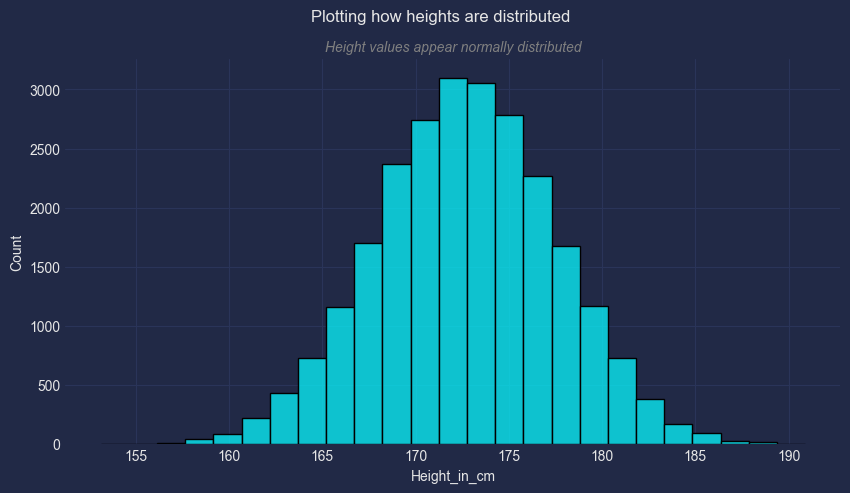

In [14]:
# Finding kind of distribution for the height values 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()


## Finding likelihood
**Q: What is the probability% that a person's height from the dataset < 172cm?**

In [15]:
height_mean = df.describe().loc["mean", "Height_in_cm"]
height_stdev  = df.describe().loc["std", "Height_in_cm"]

In [16]:
norm.cdf(172, loc= height_mean ,scale= height_stdev)

np.float64(0.44218866026199904)

>So there's a 44% chance that a person's height, selected randomly from the dataset, is less than 172cm .


**Q: What is the probability% that a person's height from the dataset > 178cm?**

In [17]:
1 - norm.cdf(178, loc=height_mean , scale=height_stdev)

np.float64(0.1363767033562957)

>So there's a 13.6% chance that a person's height, selected randomly from the dataset, is more than than 178cm .

**Q: What is the probability% that a person's height from the dataset is exactly 178cm?**

In [18]:
norm.pdf(178, loc=height_mean , scale=height_stdev)

np.float64(0.045263032907543306)

>So there's a 4.5% chance that a person's height, selected randomly from the dataset, is exactly 178cm .

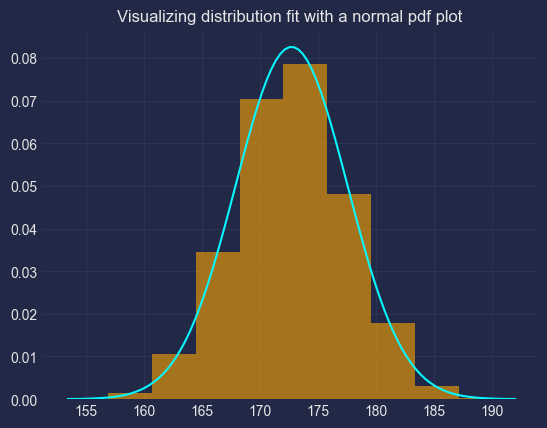

In [19]:
import scipy.stats

mu=height_mean
sigma=height_stdev

# calculating 100 evenly spaced intervals in a range
# of +/- 4 standard Deviations above / below the mean
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)
plt.hist(df["Height_in_cm"] , density=True, alpha=0.6, color='orange', label='Actual Data')
plt.title("Visualizing distribution fit with a normal pdf plot")
plt.plot(x,y)
plt.show()

If you were to run that same code with $n=500$:

- At $n=50$: Your histogram might look a bit "jagged," and the PDF curve is relatively wide.
- At $n=500$: The histogram bars would align almost perfectly with the PDF curve, and the entire structure would be much thinner and taller.

# Linear Regression
For the given `weightsheights.csv` dataset,consider:

- `height_in_cm` is explanatory (independent) variable

- `weight_in_kg` is response (dependent) variable

In [20]:
model = ols("Weight_in_kg ~ Height_in_cm", data=df).fit()
model.params

Intercept      -37.454069
Height_in_cm     0.550637
dtype: float64

### The linear equation formed is : 

Weight is calculated as: $Weight = (0.55\times Height) - 37.45$

>This means , for every 1cm increase in height, there's a 0.55X increase in the weight.

In [21]:
model.predict({"Height_in_cm":170})

0    56.154285
dtype: float64

___
# Revision of Sampling
>The method-2 (numpy + list comprehension) is fastest of the 3 methods listed below & also has minimal memory footprint. 

As for the other two, method-1(`for` loop) is simplest to understand.

In [22]:
# np.random.seed(2022)
# consider a normally-distributed dataset 
normaldf = pd.DataFrame({"val":np.round(np.random.normal(10,3.0,size=5000),2)})

### Method-1 : using `for` loop 
_using `for` loop  +  (`range` , `sample` & `mean`)  method_. 

This method is simplest to understand but compute time becomes longer as no. of samples / individual sample size grows.

**Output of below code:** each value represents a mean of one bootstrapped sample. So `bootstrapped_means` represents 1000 such means of bootstrapped samples


In [23]:
# taking bootstrapped samples
bootstrapped_means = []
for i in range(1000):
    # NOTE:size of bootstrapped sample is same as population
    bootstrapped_sample = normaldf.sample(frac=1, replace=True)
    bootstrapped_means.append(bootstrapped_sample["val"].mean())

print(len(bootstrapped_means))
print(bootstrapped_means[0:4])

1000
[np.float64(9.997916), np.float64(10.030914), np.float64(10.050146), np.float64(9.983562)]


In [24]:
# taking bootstrapped sample means of heights
btstrp_height = []
for i in range(1000):
    btstrp_heightsample = df.sample(frac=1, replace=True)
    btstrp_height.append(btstrp_heightsample["Height_in_cm"].mean())

print(len(btstrp_height))
print(btstrp_height[0:4])

1000
[np.float64(172.75566719999998), np.float64(172.6926252), np.float64(172.6803752), np.float64(172.67127759999997)]


## Method-2 : numpy conversion + list comprehension
**Code output:** is exact same as the above bootstrapping process, but its a _faster & compressed way that uses NumPy & a list comprehension_ instead of a standard `for` loop.

In [25]:
# converting the concerned column into a numpy array
heights_numpy = df['Height_in_cm'].to_numpy()
# perform sampling with replacement for 1000 times
heights_btstrpmean = [heights_numpy[np.random.randint(0,len(heights_numpy), len(heights_numpy))].mean().round(3) 
                      for _ in range(1000)]

print(f"dtype of heights_numpy : {type(heights_numpy)}")
print(f"dtype of heights_btrspmean : {type(heights_btstrpmean)}")
print(f"length of heights_btrspmean : {len(heights_btstrpmean)}")
print(f"heights_btrspmeans : {heights_btstrpmean[0:4]}")

dtype of heights_numpy : <class 'numpy.ndarray'>
dtype of heights_btrspmean : <class 'list'>
length of heights_btrspmean : 1000
heights_btrspmeans : [np.float64(172.716), np.float64(172.722), np.float64(172.722), np.float64(172.72)]


In [26]:
# this portion gives mean of one sample set (sampled with replacement)
heights_numpy[np.random.randint(0,len(heights_numpy),len(heights_numpy))].mean()

np.float64(172.6915436)

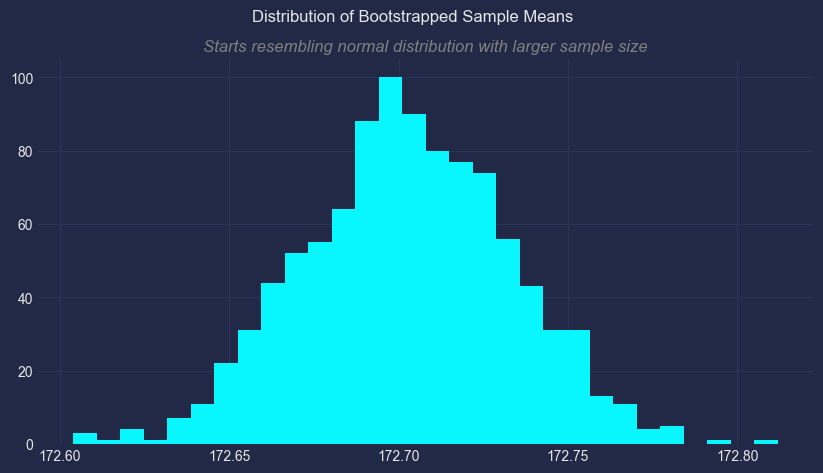

In [27]:
# plotting the distribution of the bootstrapped sample means
plt.figure(figsize=(10,5))
plt.hist(heights_btstrpmean, bins=30)
plt.title("Starts resembling normal distribution with larger sample size", fontdict={"style":"italic", "color":"grey"})
plt.suptitle("Distribution of Bootstrapped Sample Means")
plt.show()

>Proof that , as sampling size increases, the mean of all sampling mean approaches to the true population mean. (Law of large numbers) 

## Method-3 : using `scipy.stats` library's `bootstrap` module
Instead of building manual loops or index selectors, this method outsources the entire statistical process to a heavily optimized scientific library.

The scipy.stats library's `bootstrap` module contains the following params:
- `data` : df column to be sampled, it must be **passed as a Python tuple** of array-like objects
- `statistic` : tells SciPy exactly what metric you want to calculate for every single bootstrap sample (could be `np.mean` ,`np.median` etc.)
- `n_resamples` : number of bootstrapped samples to generate (default is 1000)
- `method` : the math formula to calculate the lower &  upper bounds of  confidence interval from the generated distribution.

**Output of below code:** is a `BootstrapResult` object that contains the confidence interval for the mean of the `height_in_cm` column, calculated from the bootstrapped samples. The confidence interval is typically represented as a tuple with lower and upper bounds.

In [28]:
# importing bootstrap module from scipy.stats
from scipy.stats import bootstrap
# converting concerned column into numpy array & tuple
data = (df['Height_in_cm'].to_numpy(), )
# create scipy.stats bootstrapped object
res = bootstrap(data= data, statistic=np.mean, n_resamples= 1000, method='percentile')
print(type(res))
# accessing the bootstrapped distribution
btsrp_samplemeans = res.bootstrap_distribution
print(type(btsrp_samplemeans))

<class 'scipy.stats._resampling.BootstrapResult'>
<class 'numpy.ndarray'>


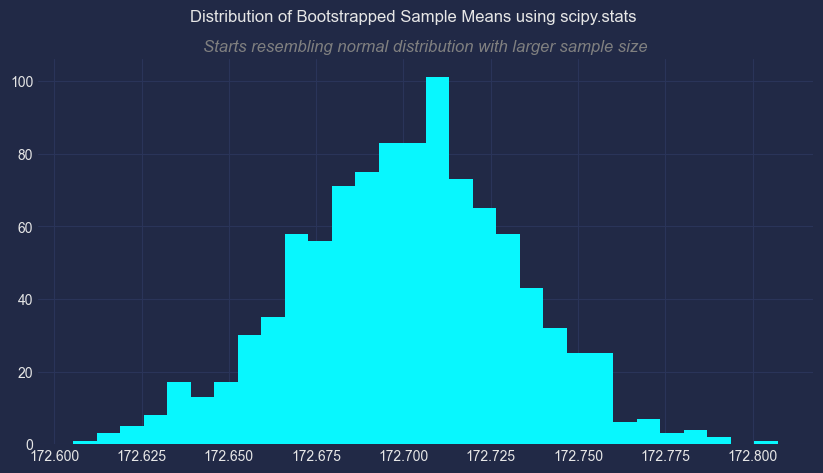

In [29]:
# plotting the btsrp distribution
plt.figure(figsize=(10,5))
plt.hist(btsrp_samplemeans, bins=30)
plt.title("Starts resembling normal distribution with larger sample size", fontdict={"style":"italic", "color":"grey"})
plt.suptitle("Distribution of Bootstrapped Sample Means using scipy.stats")
plt.show()

# Use cases for Hypothesis testing 
>**The goal of hypothesis testing is to determine whether there is enough statistical evidence to reject the null hypothesis in favor of the alternate hypothesis.**

>Its a statistical method that helps to determine if the data from sample provides enough evidence to support a specific claim about the larger population. 

A hypothesis test usually consists of 4 parts:
1. **The competing hypotheses** 

    a. **Null hypothesis (H0)**: This is the default assumption or claim that there is no effect or difference. It represents the status quo or a statement of no change.

    b **Alternative hypothesis (H1)**: This is the statement that contradicts the null
2. **Test-statistic**: Its a single numerical value calculated from sample data (z-score, t-score , f-statistic etc.) that measures how closely your observed data aligns with the null hypothesis.
3. **Significance value $(\alpha)$**: Its a pre-determined threshold for proof that's decided before looking at the data. Represents risk being taken of being wrong (Type I error / False positive - i.e. rejecting $H_0$ when it is actually true)

4. **The p-value**: the probability of observing your data, or something more extreme, under the assumption that $H_0$ is true. p-value is compared to the significance level $\alpha$ to decide whether to reject (p-value $\le \alpha$)  or fail to reject (p-value $> \alpha$) the null hypothesis.

### Errors in decision-making
1. **Type I Error /False positive ($\alpha$):** You reject the null hypothesis when it was actually true. (e.g., Convicting an innocent person, or concluding a drug works when it actually doesn't)

2. **Type II Error / False Negative ($\beta$):** You fail to reject the null hypothesis when it was actually false. (e.g., Letting a guilty person go free, or missing a breakthrough medical treatment because your sample size was too small).

In [30]:
# loading stckoverflow datasets
stackoverflowdf = pd.read_feather('./datasets/stack_overflow.feather')
print(stackoverflowdf.shape)

# loading the shipments dataset
shipments_df = pd.read_feather('./datasets/late_shipments.feather')
print(shipments_df.shape)

# loading HR dataset
ibmhr_df = pd.read_csv('./datasets/UseCase-HR-Employee-Attrition.csv')
print(ibmhr_df.shape)

(2261, 63)
(1000, 27)
(1470, 35)


## Classifying hypothesis tests
To make sense of the wide variety of hypothesis tests used in data science and statistics, effectively categorize them based on two factors:
- the type of data you have (Numerical vs. Categorical) and 
- how many groups you are comparing.

### Think of hypothesis testing as a decision tree based on three questions:
- What is the target variable type? - Numeric / binary/ Categorical
- How many groups am I comparing? - One sample to benchmark/ two-sample / 
- What question am I trying to answer? - _Are these groups different?_ OR _does change in X help predict Y?_


In [31]:
print(ibmhr_df.columns.to_list())
ibmhr_df.head()

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Performing some EDA on the HR dataset :**

In [32]:
ibmhr_df.iloc[:5,15:20]
print(ibmhr_df['JobRole'].value_counts())
print("\n")
print(ibmhr_df['EducationField'].value_counts())

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64


In [33]:
ibmhr_df.groupby(['JobRole','Attrition'])["MonthlyIncome"].mean().round(2)

JobRole                    Attrition
Healthcare Representative  No            7453.56
                           Yes           8548.22
Human Resources            No            4391.75
                           Yes           3715.75
Laboratory Technician      No            3337.22
                           Yes           2919.26
Manager                    No           17201.48
                           Yes          16797.40
Manufacturing Director     No            7289.93
                           Yes           7365.50
Research Director          No           15947.35
                           Yes          19395.50
Research Scientist         No            3328.12
                           Yes           2780.47
Sales Executive            No            6804.62
                           Yes           7489.00
Sales Representative       No            2798.44
                           Yes           2364.73
Name: MonthlyIncome, dtype: float64

**Lets train focus on Sales Executives**

difference in Avg Monthly Incomes of Sales execs with different backgrounds -- those with marketing degree vs those having technical degree

> Hypothesis: Avg monthly income of sales execs with marketing degree is higher than those with technical degree

> $H_0: \mu_{marketing} = \mu_{technical}$ and <br> 
$H_A : \mu_{marketing} - \mu_{technical} >0$

In [34]:
# finding diverse education backgrounds of Sales Execs
print(ibmhr_df[ibmhr_df['JobRole']=="Sales Executive"]['EducationField'].value_counts())

# creating a sub-dataframe
ibmsales = ibmhr_df[ibmhr_df['JobRole']=="Sales Executive"].copy()
ibmsales.head()

EducationField
Marketing           122
Life Sciences       107
Medical              65
Technical Degree     19
Other                13
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
27,42,No,Travel_Rarely,691,Sales,8,4,Marketing,1,35,...,4,80,1,10,2,3,9,7,4,2
39,33,No,Travel_Frequently,1141,Sales,1,3,Life Sciences,1,52,...,1,80,2,10,3,3,5,3,1,3
43,27,No,Travel_Frequently,994,Sales,8,3,Life Sciences,1,56,...,4,80,0,9,0,3,9,8,1,7
46,34,No,Non-Travel,1065,Sales,23,4,Marketing,1,60,...,3,80,0,10,2,3,9,5,8,7


## Salary trends for different education backgrounds
Analysing the IBM HR dataset

### 2-sample independent t-test
Comparing the mean of two independent groups (same department , different education backgrounds) via t-tests

In [52]:
# conduting basic EDA on the HR dataset
# ibmhr_df.head()
# ibmhr_df.describe()

# #finding if any columns have missing/ NaN  
# ibmhr_df.isnull().sum()

In [35]:
# 2-sample tests - Avg salary of sales execs with marketing vs those with technical degree
grp1 = ibmsales[ibmsales['EducationField']=="Marketing"]['MonthlyIncome']
grp2 = ibmsales[ibmsales['EducationField']=="Technical Degree"]['MonthlyIncome']
se_t_stat, se_p_val = stats.ttest_ind(grp1, grp2, equal_var=False, alternative='greater')
print(f"t-stat= {se_t_stat} \np_val={se_p_val}")

t-stat= -0.7121089088050128 
p_val=0.758281337502016


In [36]:
# comparing p-val with significance levle of 0.1
se_p_val < 0.1

np.False_

>Thus, we fail to reject the null hypothesis

There isn't enough statistical evidence suggesting Sales execs with a marketing background are earning more than those with technical background.

>This could help address management concerns if one sub-group is being paid more than others.

In [37]:
# using groupby to discover that actually the inverse is true 
ibmsales.groupby('EducationField')['MonthlyIncome'].mean().round()

EducationField
Life Sciences       6976.0
Marketing           7024.0
Medical             6714.0
Other               5838.0
Technical Degree    7462.0
Name: MonthlyIncome, dtype: float64

## How is MonthlyIncome associated to job satisfaction?
- Note that MonthlyIncome  _does not follow normal distribution curve_ even for sub-groups of JobSat levels. Need to look for non-parametric tests
- While ANOVA is for comparing normally distributed data stats across multiple categoricals, in this partivular case the **Kruskal-Wallis test needs to be applied**.

First, lets understand the descriptive stats of the columns/ variables involved

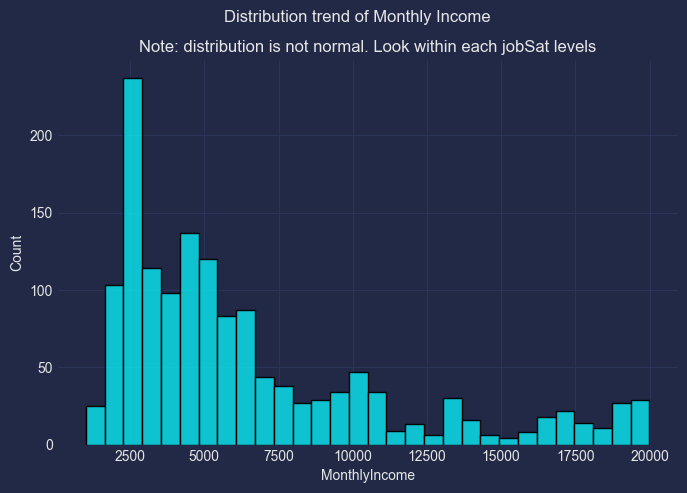

In [39]:
# Distribution trend of Monthly Income
plt.figure(figsize=(8,5))
sns.histplot(data=ibmhr_df, x='MonthlyIncome', bins=30)
plt.suptitle("Distribution trend of Monthly Income")
plt.title("Note: distribution is not normal. Look within each jobSat levels")
plt.show()

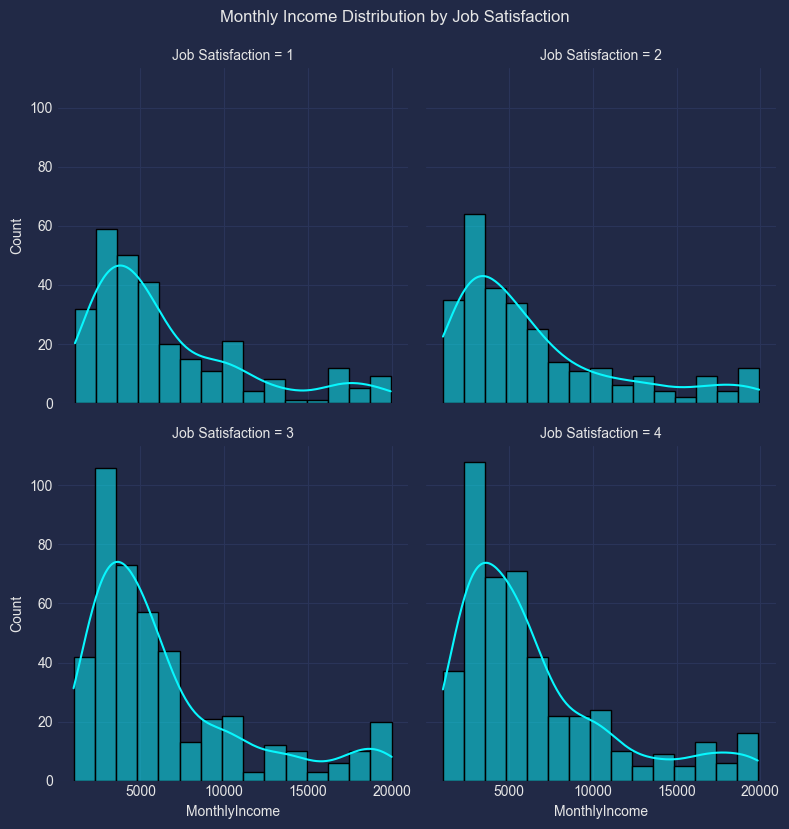

In [40]:
g = sns.FacetGrid(ibmhr_df, col='JobSatisfaction', col_wrap=2, height=4)

g.map_dataframe(sns.histplot, x='MonthlyIncome', bins=15, kde=True)

g.set_titles("Job Satisfaction = {col_name}")
g.figure.suptitle("Monthly Income Distribution by Job Satisfaction", y=1.03)
plt.show()

Thus we see that monthlyIncome does not follow normal distribution even amongst individual jobSat levels

Now plotting stats for each of the JobSat levels:

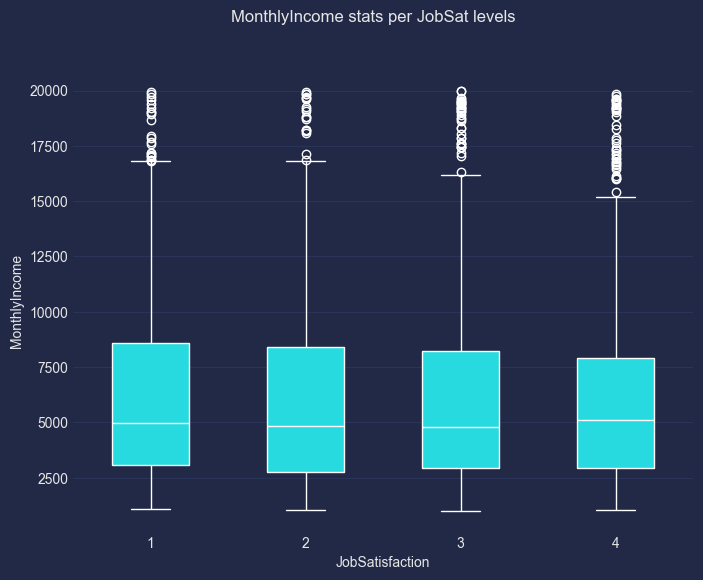

In [41]:
plt.figure(figsize=(8,6))
sns.boxplot(data=ibmhr_df, x= 'JobSatisfaction' , y= 'MonthlyIncome', width=0.5, linecolor='white')
plt.suptitle("MonthlyIncome stats per JobSat levels")
plt.show()

## Studying Attrition by jobRoles

In [42]:
ibmhr_df.groupby(['JobRole', 'Attrition'])['Attrition'].count()

JobRole                    Attrition
Healthcare Representative  No           122
                           Yes            9
Human Resources            No            40
                           Yes           12
Laboratory Technician      No           197
                           Yes           62
Manager                    No            97
                           Yes            5
Manufacturing Director     No           135
                           Yes           10
Research Director          No            78
                           Yes            2
Research Scientist         No           245
                           Yes           47
Sales Executive            No           269
                           Yes           57
Sales Representative       No            50
                           Yes           33
Name: Attrition, dtype: int64

In [43]:
jb_list = ibmhr_df['JobRole'].unique().tolist()
jb_list.sort()
print(jb_list)

['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']


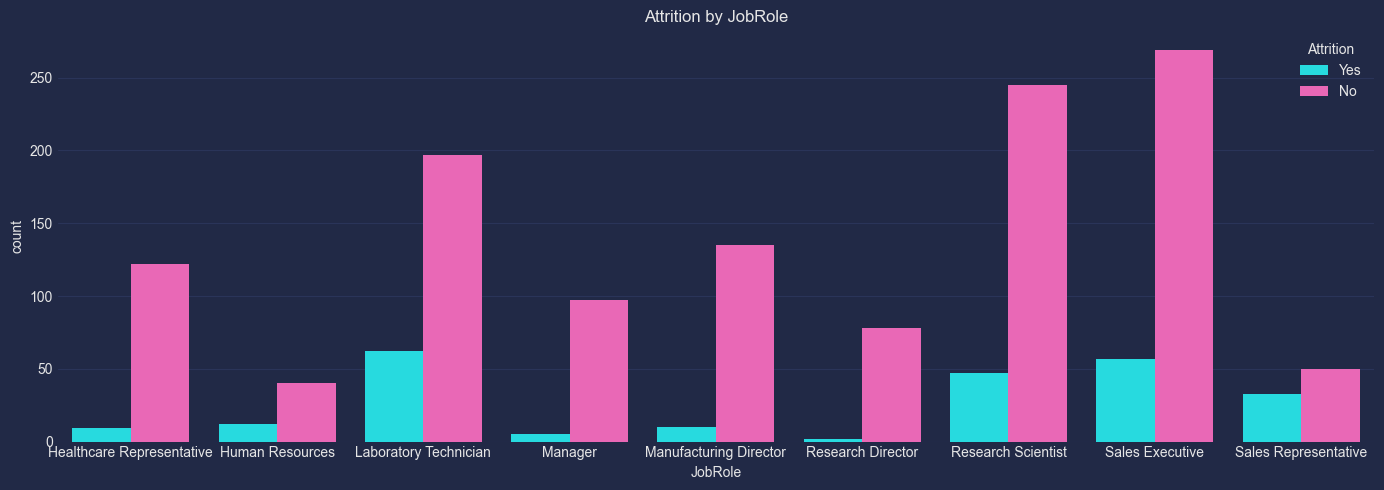

In [44]:
plt.figure(figsize=(14,5))
sns.countplot(data=ibmhr_df, x='JobRole', hue='Attrition',  order=jb_list ,)
plt.title("Attrition by JobRole")
plt.tight_layout()
plt.show()